# **Backgrounds Generator**

## **Libraries**

In [3]:
from PIL import Image, ImageOps
from io import BytesIO
from pathlib import Path
from google import genai
import base64
import openai
import getpass
import os
import matplotlib.pyplot as plt

BASE_OUTPUT_DIR = "../../data/prc/backgrounds/"

print(f"OpenAI version: {openai.__version__}")
print(f"GenAI version: {genai.__version__}")
print(f"PIL version: {Image.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

OpenAI version: 2.48.0
GenAI version: 2.14.0
PIL version: 12.3.0
Matplotlib version: 3.11.0


## **Image generation tests with gpt-image-1**

In [33]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")
    openai.api_key = os.environ["OPENAI_API_KEY"]

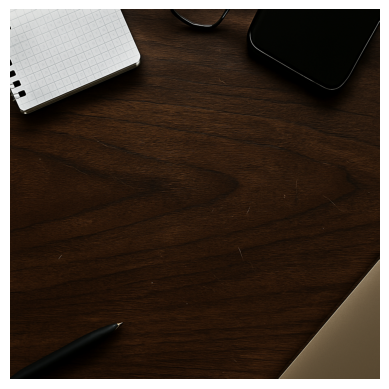

In [34]:
image_prompt = "Fotografía cenital estilo flatlay de la superficie de un escritorio de madera oscura con vetas naturales y pequeños rayones, luz natural suave que entra desde un costado, foto tomada con celular, textura realista, centro vacío y despejado"

client = openai.OpenAI()
try:
    result = client.images.generate(
        model="gpt-image-1",
        prompt=image_prompt,
        size="1024x1024"
    )
except Exception as e:
    print(f"Error generating image: {e}")
    exit(1)

image_base64 = result.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

image = Image.open(BytesIO(image_bytes))
plt.imshow(image)
plt.axis('off')
plt.show()

* Save the image generated.

In [ ]:
with open(os.path.join(BASE_OUTPUT_DIR, "generated_image.png"), "wb") as f:
    f.write(image_bytes)

In [9]:
def generate_openai_image(prompt, output_path):
    client = openai.OpenAI()
    try:
        result = client.images.generate(
            model="gpt-image-1",
            prompt=prompt,
            size="1024x1024"
        )
        image_base64 = result.data[0].b64_json
        image_bytes = base64.b64decode(image_base64)
        image = Image.open(BytesIO(image_bytes))
        plt.imshow(image)
        plt.axis('off')
        plt.show()
        with open(output_path, "wb") as f:
            f.write(image_bytes)
    except Exception as e:
        print(f"Error generating image: {e}")
        return

In [ ]:
prompts = [
    "Vista superior directa de una mesada de granito o mármol claro, iluminación cálida de interiores, superficie con textura natural, fotografía casual de smartphone, sin objetos en el centro",
    "Plano cenital de un mantel de lino beige sobre una mesa de comedor, tejido de tela visible y realista, luz de día neutra, toma directa desde arriba, fondo limpio",
    "Textura de asiento de auto de tela gris oscura, perspectiva cenital, luz del sol filtrándose por la ventana, fotorrealista, enfoque de textura",
]

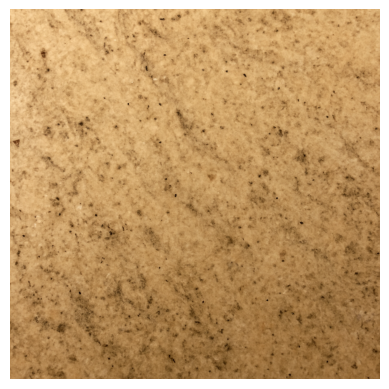

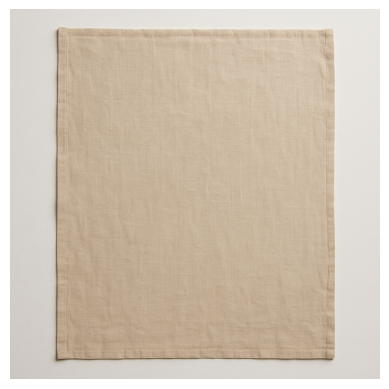

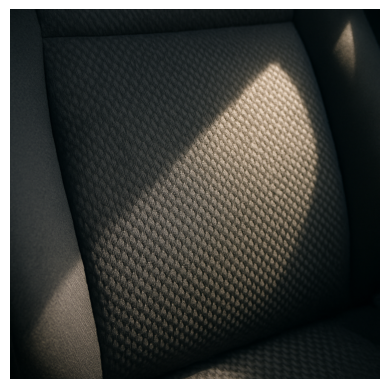

In [17]:
IMAGES = os.listdir(BASE_OUTPUT_DIR)
IMAGES = [int(img.split('.')[0]) for img in IMAGES]
MAX_IMAGE_NUMBER = max(IMAGES) if IMAGES else 0


for prompt in prompts:
    MAX_IMAGE_NUMBER += 1
    output_path = os.path.join(BASE_OUTPUT_DIR, f"{MAX_IMAGE_NUMBER}.png")
    generate_openai_image(prompt, output_path)

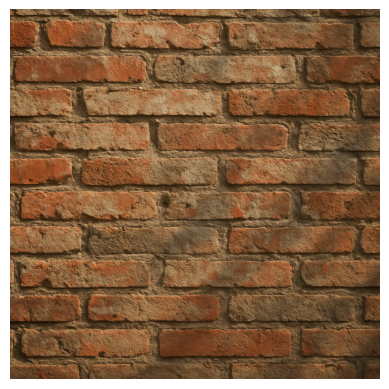

In [18]:
prompt = "Vista de una pared de ladrillos algo desgastados, con textura rugosa, iluminacion natural suave, algunas sombras"
generate_openai_image(prompt, os.path.join(BASE_OUTPUT_DIR, f"{MAX_IMAGE_NUMBER + 1}.png"))

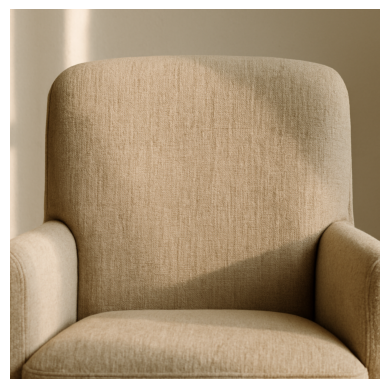

In [ ]:
prompt = "Fotografia de frente con zoom de una silla de living. Iluminacion natural. No debe verse todo la silla solo el respaldar"
# MAX_IMAGE_NUMBER = MAX_IMAGE_NUMBER + 2
generate_openai_image(prompt, os.path.join(BASE_OUTPUT_DIR, f"{MAX_IMAGE_NUMBER + 2}.png"))

## **Image Generation tests with Gemini**

In [23]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google: ")

In [31]:
def generate_image_gemini(model, prompt, output_path):

    client = genai.Client()

    response = client.models.generate_content(
        model=model,
        contents=[prompt],
    )

    for part in response.candidates[0].content.parts:
        if part.text is not None:
            print(part.text)
        elif part.inline_data is not None:
            image = Image.open(BytesIO(part.inline_data.data))
            image.save(output_path)

            plt.imshow(image)
            plt.axis('off')
            plt.show()

    return image

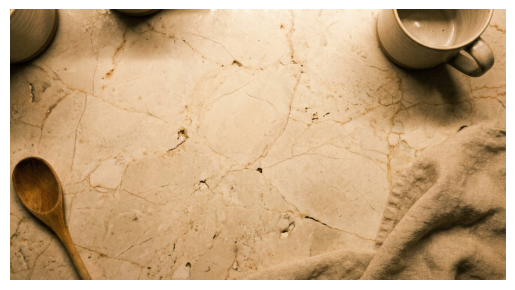

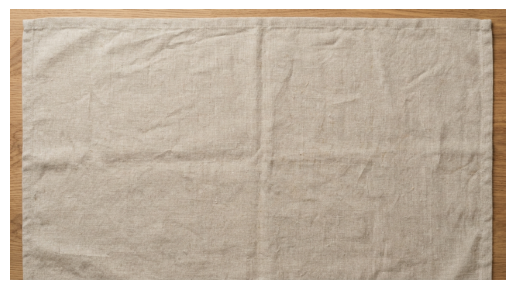

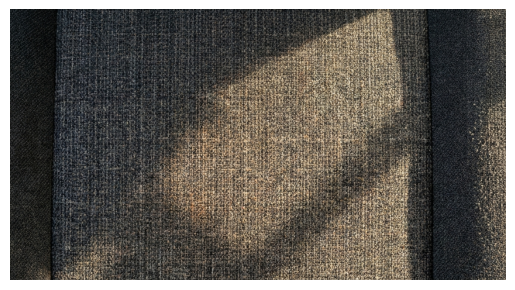

In [32]:
for prompt in prompts:
    MAX_IMAGE_NUMBER += 1
    output_path = os.path.join(BASE_OUTPUT_DIR, f"{MAX_IMAGE_NUMBER}.png")
    prompt += ". La imagen debe ser de alta calidad y resolucion."
    generate_image_gemini("gemini-3-pro-image", prompt, output_path)

After generate some images with differents vision models from `openai` and `gen-ai` frameworks, we have 35 backgrounds images.

This set of images included the AI generated images as a mention before and also include photos taken by myself with my phone. For this reason we have different resolutions for our images. 

So to do a better work, now is recommended to do a post processing for our set. 

In this process, we will take all images in the input folder, correcting their EXIF orientation.
Converting to RGB if necessary and resizing/cropping from  the center to 1024x1024.

In [ ]:
def process_backgrounds(input_folder: str, ouput_folder: str, size: tuple=(1024, 1024)):
    """
    Processes all images in the input folder, correcting their EXIF orientation,
    converting to RGB if necessary, and resizing/cropping to the specified size.
    """
    source_path = Path(input_folder)
    out_path = Path(ouput_folder)
    os.makedirs(out_path, exist_ok=True)
    processed_count = 0
    for image_file in source_path.iterdir():
        print(f"Processing {image_file}...")
        with Image.open(image_file) as img:
            # Fit the image rotation based on EXIF data
            img = ImageOps.exif_transpose(img)

            # Convert to RGB if is a gray scale or PNG transparent image
            if img.mode in ("RGBA", "P"):
                img = img.convert("RGB")

            # Cover and center crop
            crop_img = ImageOps.fit(img, size, method=Image.Resampling.LANCZOS)

            # Save the processed image
            out_file = out_path / image_file.name
            crop_img.save(out_file, "JPEG", quality=95)
            processed_count += 1

    print(f"Processed {processed_count} images from {input_folder} to {ouput_folder}.")

In [42]:
process_backgrounds("../../data/prc/backgrounds",
                     "../../data/prc/backgrounds_1024", 
                     size=(1024, 1024))

Processing ../../data/prc/backgrounds/2.jpeg...
Processing ../../data/prc/backgrounds/1.jpeg...
Processing ../../data/prc/backgrounds/8.jpeg...
Processing ../../data/prc/backgrounds/19.jpeg...
Processing ../../data/prc/backgrounds/14.jpeg...
Processing ../../data/prc/backgrounds/12.jpeg...
Processing ../../data/prc/backgrounds/28.png...
Processing ../../data/prc/backgrounds/31.png...
Processing ../../data/prc/backgrounds/13.jpeg...
Processing ../../data/prc/backgrounds/23.png...
Processing ../../data/prc/backgrounds/34.png...
Processing ../../data/prc/backgrounds/10.jpeg...
Processing ../../data/prc/backgrounds/21.png...
Processing ../../data/prc/backgrounds/5.jpeg...
Processing ../../data/prc/backgrounds/35.png...
Processing ../../data/prc/backgrounds/24.png...
Processing ../../data/prc/backgrounds/17.jpeg...
Processing ../../data/prc/backgrounds/22.png...
Processing ../../data/prc/backgrounds/33.png...
Processing ../../data/prc/backgrounds/11.jpeg...
Processing ../../data/prc/backgro